# 실험설계

- 원하는 결과나 한가지 변수에 대한 차이를 보고싶다면 실험 계획을 확실히 하고 들어가는게 좋습니다


# 사용자 정의 루프

- vocasize, model을 리스트 및 딕셔너리로 잡고 for문 두번으로 전체 실험돌리기

- vocab_sizes = [1500, 3000, 5000, 10000, None] # None은 모든 단어 사용  

models = {   
    "Naive Bayes": MultinomialNB(),   
    "Logistic Regression": LogisticRegression(max_iter=1000,    solver='liblinear'),   
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1)   
}



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import reuters
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Reuters 데이터를 텍스트로 복원하는 함수 (CountVectorizer 사용을 위해)
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word

    decoded_docs = []
    for sequence in x_data:
        decoded_docs.append(' '.join([index_to_word.get(i, '?') for i in sequence]))
    return decoded_docs

# 2. 실험 설정
vocab_sizes = [1500, 3000, 5000, 10000, None] # None은 모든 단어 사용
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1)
}

results = []

# 3. 실험 루프
for size in vocab_sizes:
    print(f"--- Experimenting with Vocab Size: {size if size else 'All'} ---")

    # 데이터 로드
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)

    # 텍스트 복원
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    # TF-IDF 벡터화
    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    # 모델별 학습 및 평가
    for name, model in models.items():
        model.fit(x_train_tfidf, y_train)
        predicted = model.predict(x_test_tfidf)

        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        results.append({
            "Vocab Size": size if size else "Full",
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

# 4. 결과 정리
df_results = pd.DataFrame(results)
print("\n[실험 결과 요약]")
print(df_results)

--- Experimenting with Vocab Size: 1500 ---
2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
--- Experimenting with Vocab Size: 3000 ---
--- Experimenting with Vocab Size: 5000 ---
--- Experimenting with Vocab Size: 10000 ---
--- Experimenting with Vocab Size: All ---

[실험 결과 요약]
   Vocab Size                Model  Accuracy  F1 Score
0        1500          Naive Bayes  0.691451  0.642744
1        1500  Logistic Regression  0.788513  0.761827
2        1500        Random Forest  0.778718  0.760347
3        3000          Naive Bayes  0.687444  0.626617
4        3000  Logistic Regression  0.791184  0.766274
5        3000        Random Forest  0.774711  0.754505
6        5000          Naive Bayes  0.673197  0.601250
7        5000  Logistic Regression  0.790294  0.764820
8        5000        Random Forest  0.765361  0.742640
9       10000          Naive Bayes  0.656723  0.576447
10      10000  Logistic Regression  0.787622  0.761266
11      1000

/tmp/ipython-input-3153234888.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot['Vocab Size'] = df_plot['Vocab Size'].replace("Full", 31000)


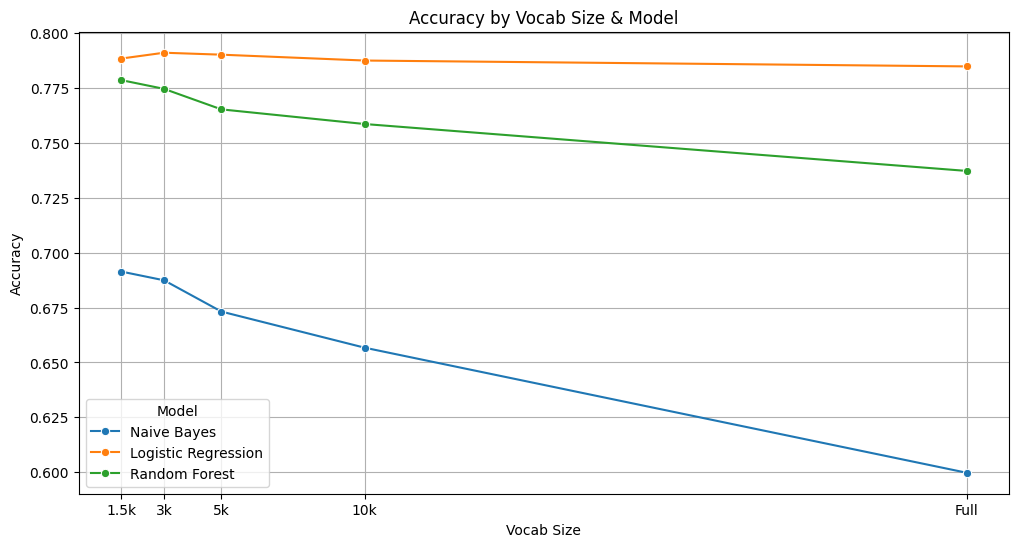

In [ ]:
# 1. 에러 수정을 위해 데이터프레임 복사
df_plot = df_results.copy()

# 2. "Full" 문자열을 그래프에 표시될 적당한 숫자(예: 31000)로 변경
# Reuters 전체 단어 수가 대략 3만 개 정도 됩니다.
df_plot['Vocab Size'] = df_plot['Vocab Size'].replace("Full", 31000)

# 3. 데이터 타입을 숫자로 강제 변환 (안전장치)
df_plot['Vocab Size'] = pd.to_numeric(df_plot['Vocab Size'])

# 4. 시각화 다시 실행
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x="Vocab Size", y="Accuracy", hue="Model", marker='o')

# X축 눈금을 예쁘게 만들기 위해 "Full" 위치에 텍스트 표시 (선택 사항)
plt.xticks(ticks=[1500, 3000, 5000, 10000, 31000], labels=['1.5k', '3k', '5k', '10k', 'Full'])

plt.title("Accuracy by Vocab Size & Model")
plt.grid(True)
plt.show()

# 참고용

# AutoML 라이브러리인 PyCaret
- 위에꺼 하고 돌리면 메모리 터져서
- 런타임 다시 시작하고 여기 돌려야합니다
   
- 해보려~~~ 했는데pycaret은 python 3.11까지만 지워 colab은 3.12

# AutoML 라이브러리 AutoGluon
- 중간에 colab RAM이 터져서 10000개랑 전체는 뺏습니다

In [ ]:
# 라이브러리 설치를 해줘야합니다
!pip install autogluon

In [ ]:
import pandas as pd
from tensorflow.keras.datasets import reuters
from sklearn.feature_extraction.text import TfidfVectorizer
from autogluon.tabular import TabularPredictor

# 1. 데이터 준비 함수
def get_reuters_data(vocab_size):
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=vocab_size)
    word_index = reuters.get_word_index()
    idx_to_word = {i+3: w for w, i in word_index.items()}
    for i, w in enumerate(('<pad>', '<sos>', '<unk>')): idx_to_word[i] = w

    train_text = [' '.join([idx_to_word.get(i, '?') for i in seq]) for seq in x_train]
    test_text = [' '.join([idx_to_word.get(i, '?') for i in seq]) for seq in x_test]
    return train_text, y_train, test_text, y_test

vocab_sizes = [1500, 3000, 5000]
results = []

for size in vocab_sizes:
    print(f"\n--- ⚡ 실험 시작: Vocab Size {size} ---")

    train_text, y_train, test_text, y_test = get_reuters_data(size)
    tfidf = TfidfVectorizer(max_features=size)

    X_train = pd.DataFrame(tfidf.fit_transform(train_text).toarray())
    X_train['label'] = y_train
    X_test = pd.DataFrame(tfidf.transform(test_text).toarray())
    X_test['label'] = y_test

    predictor = TabularPredictor(label='label', verbosity=0).fit(
        X_train, time_limit=120, presets='medium_quality'
    )

    # 1등 모델 이름 가져오기
    best_model_name = predictor.model_best

    # 성능 평가
    performance = predictor.evaluate(X_test)
    acc = performance['accuracy']

    print(f"✅ Vocab Size {size} 완료! [Best Model: {best_model_name}]")
    results.append({
        'Vocab_Size': size,
        'Accuracy': acc,
        'Best_Model': best_model_name
    })

# 결과 출력
df_res = pd.DataFrame(results)
print("\n" + "="*50)
print("🏆 Vocab Size별 최적 모델 요약")
print(df_res)
print("="*50)


--- ⚡ 실험 시작: Vocab Size 1500 ---
✅ Vocab Size 1500 완료! [Best Model: WeightedEnsemble_L2]

--- ⚡ 실험 시작: Vocab Size 3000 ---
✅ Vocab Size 3000 완료! [Best Model: WeightedEnsemble_L2]

--- ⚡ 실험 시작: Vocab Size 5000 ---
✅ Vocab Size 5000 완료! [Best Model: WeightedEnsemble_L2]

🏆 Vocab Size별 최적 모델 요약
   Vocab_Size  Accuracy           Best_Model
0        1500  0.823241  WeightedEnsemble_L2
1        3000  0.822351  WeightedEnsemble_L2
2        5000  0.817898  WeightedEnsemble_L2


In [ ]:
# 1. 1등 모델 정보 가져오기
best_model = predictor.model_best
model_info = predictor.info()['model_info'][best_model]

print(f"🧐 1등 모델: {best_model}")

# 2. 가중치 추출 시도
weights = None

# 방법 A: 'weights' 키가 직접 존재하는 경우 (최신 버전)
if 'weights' in model_info:
    weights = model_info['weights']

# 방법 B: 'stacker_info' 안에 'weights'가 있는 경우
elif 'stacker_info' in model_info and 'weights' in model_info['stacker_info']:
    weights = model_info['stacker_info']['weights']

# 방법 C: 'children_info'에서 추출 (구 버전 혹은 특정 설정)
elif 'children_info' in model_info:
    # children_info는 보통 {모델명: {속성들}} 구조입니다.
    print(" - 앙상블 구성 모델 (가중치는 모델 상세 정보 확인 필요):")
    for child in model_info['children_info']:
        print(f"   > {child}")

# 3. 결과 출력
if weights:
    print(f"\n📊 앙상블 내부 가중치 구성:")
    # weights가 dict 형태면 바로 출력, 아니면 다른 처리
    if isinstance(weights, dict):
        for m_name, w in weights.items():
            if w > 0: # 가중치가 0인 모델은 제외
                print(f" - {m_name}: {w:.4f}")
    else:
        print(f" - 가중치 리스트: {weights}")
else:
    if 'children_info' not in model_info:
        print("\n✨ 이 모델은 단일 모델이거나 가중치 정보를 찾을 수 없는 앙상블입니다.")

🧐 1등 모델: WeightedEnsemble_L2
 - 앙상블 구성 모델 (가중치는 모델 상세 정보 확인 필요):
   > S1F1


# wandb 실험


In [ ]:
!pip install autogluon wandb
import wandb
wandb.login()

In [ ]:
import pandas as pd
import numpy as np
import wandb
from tensorflow.keras.datasets import reuters
from sklearn.feature_extraction.text import TfidfVectorizer
from autogluon.tabular import TabularPredictor

# [기존 데이터 함수]
def get_reuters_data(vocab_size):
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=vocab_size)
    word_index = reuters.get_word_index()
    idx_to_word = {i+3: w for w, i in word_index.items()}
    for i, w in enumerate(('<pad>', '<sos>', '<unk>')): idx_to_word[i] = w
    train_text = [' '.join([idx_to_word.get(i, '?') for i in seq]) for seq in x_train]
    test_text = [' '.join([idx_to_word.get(i, '?') for i in seq]) for seq in x_test]
    return train_text, y_train, test_text, y_test

# --- 실험 설정 ---
project_name = "reuters-autogluon-optimization"
vocab_sizes = [1500, 3000, 5000]

for size in vocab_sizes:
    # 1. WandB 초기화
    run = wandb.init(
        project=project_name,
        name=f"experiment_vocab_{size}",
        config={
            "vocab_size": size,
            "presets": "medium_quality",
            "time_limit": 120,
            "feature_type": "tfidf"
        }
    )

    # 2. 데이터 준비
    train_text, y_train, test_text, y_test = get_reuters_data(size)
    tfidf = TfidfVectorizer(max_features=size)
    X_train = pd.DataFrame(tfidf.fit_transform(train_text).toarray())
    X_train['label'] = y_train
    X_test = pd.DataFrame(tfidf.transform(test_text).toarray())
    X_test['label'] = y_test

    # 3. AutoGluon 학습
    predictor = TabularPredictor(label='label', verbosity=0).fit(
        X_train,
        time_limit=run.config.time_limit,
        presets=run.config.presets
    )

    # 4. 성능 평가 및 리더보드 추출
    performance = predictor.evaluate(X_test)
    leaderboard = predictor.leaderboard(X_test, silent=True)

    # 5. [중요] 앙상블 내부 모델 가중치 추출 (안전한 버전)
    model_best = predictor.model_best
    model_info = predictor.info()['model_info'].get(model_best, {})

    ensemble_weights = []

    # 가중치 정보를 찾는 여러 가지 경로 탐색
    # 1순위: 'weights' 키가 직접 있는 경우
    weights = model_info.get('weights')

    # 2순위: 'stacker_info' 안에 'weights'가 있는 경우
    if not weights and 'stacker_info' in model_info:
        weights = model_info['stacker_info'].get('weights')

    # 추출된 가중치가 있다면 리스트로 정리
    if weights and isinstance(weights, dict):
        for m_name, w in weights.items():
            if w > 0: # 기위도가 있는 모델만 기록
                # S1F1 같은 이름 대신 실제 모델 타입(LGBM 등)을 병기하면 좋지만,
                # 일단 이름 그대로 테이블에 담습니다.
                ensemble_weights.append([m_name, w])

    # 6. WandB에 로그 전송
    wandb.log({
        "accuracy": performance['accuracy'],
        "balanced_accuracy": performance['balanced_accuracy'],
        "best_model_name": model_best
    })

    # 리더보드 전송
    wandb.log({"leaderboard_table": wandb.Table(dataframe=leaderboard)})

    # 가중치 차트 전송 (데이터가 있을 때만)
    if ensemble_weights:
        weight_table = wandb.Table(data=ensemble_weights, columns=["model_name", "weight"])
        wandb.log({
            "ensemble_weights_chart": wandb.plot.bar(
                weight_table, "model_name", "weight", title=f"Ensemble Weights (Vocab: {size})"
            )
        })
    else:
        print(f"⚠️ {model_best}의 가중치 정보를 찾을 수 없어 차트 생성을 건너뜁니다.")

    # (3) 앙상블 가중치를 막대그래프로 시각화 (테이블 형태)
    if ensemble_weights:
        weight_table = wandb.Table(data=ensemble_weights, columns=["model_name", "weight"])
        wandb.log({"ensemble_weights_chart": wandb.plot.bar(weight_table, "model_name", "weight", title="Ensemble Weights")})

    print(f"🚀 Vocab Size {size} 실험 결과가 WandB 대시보드로 전송되었습니다.")
    run.finish()

⚠️ WeightedEnsemble_L2의 가중치 정보를 찾을 수 없어 차트 생성을 건너뜁니다.
🚀 Vocab Size 1500 실험 결과가 WandB 대시보드로 전송되었습니다.


accuracy,▁
balanced_accuracy,▁
accuracy,0.82324
balanced_accuracy,0.59832
best_model_name,WeightedEnsemble_L2


⚠️ WeightedEnsemble_L2의 가중치 정보를 찾을 수 없어 차트 생성을 건너뜁니다.
🚀 Vocab Size 3000 실험 결과가 WandB 대시보드로 전송되었습니다.


accuracy,▁
balanced_accuracy,▁
accuracy,0.82235
balanced_accuracy,0.60445
best_model_name,WeightedEnsemble_L2


⚠️ WeightedEnsemble_L2의 가중치 정보를 찾을 수 없어 차트 생성을 건너뜁니다.
🚀 Vocab Size 5000 실험 결과가 WandB 대시보드로 전송되었습니다.


accuracy,▁
balanced_accuracy,▁
accuracy,0.8179
balanced_accuracy,0.5817
best_model_name,WeightedEnsemble_L2


In [ ]:
import pandas as pd
import numpy as np
import wandb
from tensorflow.keras.datasets import reuters
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. 데이터 복원 함수
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word
    return [' '.join([index_to_word.get(i, '?') for i in seq]) for seq in x_data]

# 2. 중요 단어 추출 함수 (모델별 가중치/중요도 계산)
def get_top_features(model, vectorizer, n=20):
    feature_names = vectorizer.get_feature_names_out()

    # 모델별 중요도 추출 방식 분기
    if hasattr(model, 'coef_'): # Logistic Regression
        # 다중 클래스이므로 클래스별 가중치의 절대값 평균을 사용
        importances = np.mean(np.abs(model.coef_), axis=0)
    elif hasattr(model, 'feature_importances_'): # Random Forest
        importances = model.feature_importances_
    elif hasattr(model, 'feature_log_prob_'): # Naive Bayes
        # 로그 확률의 분산을 통해 변별력이 높은 단어 추출
        importances = np.var(model.feature_log_prob_, axis=0)
    else:
        return None

    indices = np.argsort(importances)[-n:]
    return [[feature_names[i], importances[i]] for i in indices[::-1]]

# 3. 실험 설정
vocab_sizes = [1500, 3000, 5000, None]
models_dict = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=20)
}

# 4. 루프 시작
for size in vocab_sizes:
    size_label = size if size else "Full"

    # 데이터 로딩 및 전처리
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    for model_name, model in models_dict.items():
        # WandB 실험 시작
        run = wandb.init(
            project="reuters-ml-classic",
            name=f"{model_name}_{size_label}",
            config={
                "vocab_size": size_label,
                "model": model_name,
                "params": model.get_params() # 모델 파라미터 자동 기록
            },
            reinit=True
        )

        # 학습 및 예측
        model.fit(x_train_tfidf, y_train)
        predicted = model.predict(x_test_tfidf)

        # 지표 계산
        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        # 1. 기본 지표 로깅
        wandb.log({"accuracy": acc, "f1_score": f1})

        # 2. 단어 가중치(Feature Importance) 로깅
        top_features = get_top_features(model, dtmvector, n=20)
        if top_features:
            table = wandb.Table(data=top_features, columns=["word", "importance"])
            wandb.log({
                "feature_importance_chart": wandb.plot.bar(
                    table, "word", "importance", title=f"Top 20 Features ({model_name})"
                )
            })

        print(f"✅ {model_name} (Size: {size_label}) 완료 - Acc: {acc:.4f}")
        run.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hc-park (hc-park-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


✅ Naive Bayes (Size: 1500) 완료 - Acc: 0.6915


accuracy,▁
f1_score,▁
accuracy,0.69145
f1_score,0.64274


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


✅ Logistic Regression (Size: 1500) 완료 - Acc: 0.7885


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


✅ Logistic Regression (Size: Full) 완료 - Acc: 0.7850


accuracy,▁
f1_score,▁
accuracy,0.78495
f1_score,0.75719


✅ Random Forest (Size: Full) 완료 - Acc: 0.6790


accuracy,▁
f1_score,▁
accuracy,0.67898
f1_score,0.6237
